In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

In [2]:

# Read a thermodynamic trajectory file with the same format as
# Data/Original_files/nsm_representative.dat:
#   columns -> time[s], T9[GK], density[g/cm^3], R[km], Ye

def read_trajectory(filepath):
    data = np.genfromtxt(filepath, comments='#')
    return {
        'time': data[:, 0],
        'T9': data[:, 1],
        'density': data[:, 2],
        'R': data[:, 3],
        'Ye': data[:, 4],
        'name': os.path.splitext(os.path.basename(filepath))[0],
    }

file = 'Data/Original_files/NSM_Trajectories/nsm_representative.dat'
traj = read_trajectory(file)

def read_trajectory_WinNet_out(filepath):
    data = np.genfromtxt(filepath, comments='#')
    return {
        'time': data[:, 1],
        'T9': data[:, 2],
        'density': data[:, 3],
        'R': data[:, 5],
        'Ye': data[:, 4],
        'name': os.path.splitext(os.path.basename(filepath))[0],
    }

file_WinNet_out = 'Runs/Run_1/mainout.dat'
traj_WinNet_out = read_trajectory_WinNet_out(file_WinNet_out)

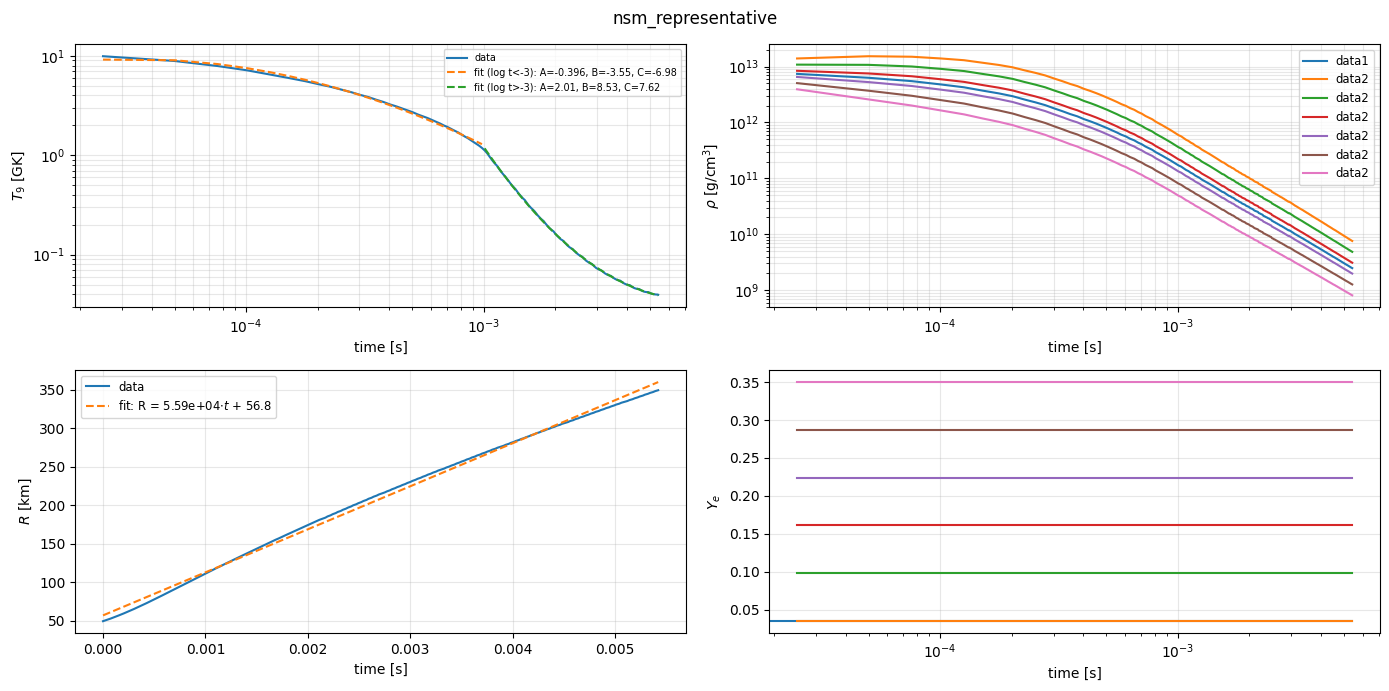

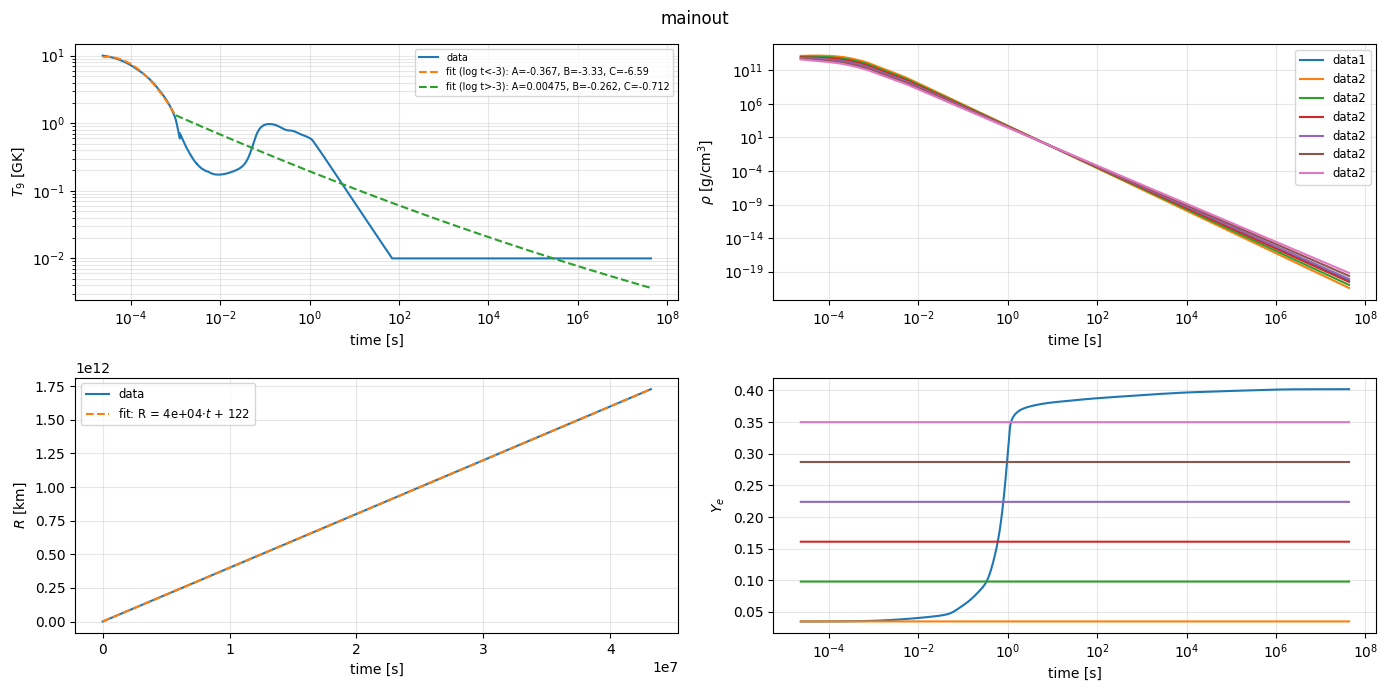

In [3]:
def fit_R_linear(traj):
    slope, intercept = np.polyfit(traj['time'], traj['R'], 1)
    return slope, intercept

def fit_logT9_quadratic_split(traj, split=-3.0):
    """Two quadratic fits of log(T9) vs log(t), split at log(t) = split."""
    mask = traj['time'] > 0
    logt = np.log10(traj['time'][mask])
    logT9 = np.log10(traj['T9'][mask])

    low = logt < split
    high = ~low

    coeffs_low = np.polyfit(logt[low], logT9[low], 2) if low.sum() >= 3 else None
    coeffs_high = np.polyfit(logt[high], logT9[high], 2) if high.sum() >= 3 else None
    return coeffs_low, coeffs_high

def modulations_exp(traj,min,max,n,a):
    mask = traj['time'] > 0
    logt = np.log10(traj['time'][mask])
    perturbations=np.linspace(1-min,1-max, n)
    modulations = [1+p*1.1-(p)*np.exp(-a*(logt+5)) for p in perturbations]
    return modulations

def perturbation_Ye(traj, min=0.035, max=0.45, n=6):
    mask = traj['time'] > 0
    logt = np.log10(traj['time'][mask])
    perturbations = np.linspace(min, max, n)
    perturbed_Ye = [np.zeros_like(traj['Ye'][mask]) + p for p in perturbations]
    return perturbed_Ye


def plot_trajectory(traj, figsize=(14, 7), split=-3.0):
    
    fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=False)

    slope, intercept = fit_R_linear(traj)
    R_fit = slope * traj['time'] + intercept

    mask = traj['time'] > 0
    logt = np.log10(traj['time'][mask])

    modulations = modulations_exp(traj, min=0.5, max=2, n=6, a=1)  # Example modulation

    # T9: log-log vs time, with two quadratic fits split at log(t) = split
    ax_T9 = axes.flat[0]
    ax_T9.plot(traj['time'][mask], traj['T9'][mask], label='data')
    coeffs_low, coeffs_high = fit_logT9_quadratic_split(traj, split=split)
    if coeffs_low is not None:
        t_low = traj['time'][mask][logt < split]
        T9_low_fit = 10 ** np.polyval(coeffs_low, np.log10(t_low))
        A, B, C = coeffs_low
        ax_T9.plot(t_low, T9_low_fit, '--',
                   label=f'fit (log t<{split:g}): A={A:.3g}, B={B:.3g}, C={C:.3g}')
    if coeffs_high is not None:
        t_high = traj['time'][mask][logt >= split]
        T9_high_fit = 10 ** np.polyval(coeffs_high, np.log10(t_high))
        A, B, C = coeffs_high
        ax_T9.plot(t_high, T9_high_fit, '--',
                   label=f'fit (log t>{split:g}): A={A:.3g}, B={B:.3g}, C={C:.3g}')
    ax_T9.set_xscale('log')
    ax_T9.set_yscale('log')
    ax_T9.set_ylabel(r'$T_9$ [GK]')
    ax_T9.set_xlabel('time [s]')
    ax_T9.grid(alpha=0.3, which='both')
    ax_T9.legend(fontsize='x-small')

    # density: log-log vs time, with a quadratic fit of log(rho) vs log(t)
    ax_rho = axes.flat[1]
    modulations2 = modulations_exp(traj, min=0.95, max=1.05, n=6, a=1)  # Example modulation
    ax_rho.plot(traj['time'][mask], traj['density'][mask], label='data1')
    for mod in modulations2:
        ax_rho.plot(traj['time'][mask], traj['density'][mask]**mod, label='data2')
    ax_rho.set_xscale('log')
    ax_rho.set_yscale('log')
    ax_rho.set_ylabel(r'$\rho$ [g/cm$^3$]')
    ax_rho.set_xlabel('time [s]')
    ax_rho.grid(alpha=0.3, which='both')
    ax_rho.legend(fontsize='small')

    # R: data + linear fit
    ax_R = axes.flat[2]
    ax_R.plot(traj['time'], traj['R'], label='data')
    ax_R.plot(traj['time'], R_fit, '--',
              label=f'fit: R = {slope:.3g}$\\cdot t$ + {intercept:.3g}')
    ax_R.set_ylabel(r'$R$ [km]')
    ax_R.set_xlabel('time [s]')
    ax_R.grid(alpha=0.3)
    ax_R.legend(fontsize='small')

    # Ye
    ax_Ye = axes.flat[3]
    ax_Ye.plot(traj['time'], traj['Ye'])
    for perturbed_Ye in perturbation_Ye(traj, min=0.035, max=0.35, n=6):
        ax_Ye.plot(traj['time'][mask], perturbed_Ye)
    ax_Ye.set_ylabel(r'$Y_e$')
    ax_Ye.set_xscale('log')
    ax_Ye.set_xlabel('time [s]')
    ax_Ye.grid(alpha=0.3)

    

    fig.suptitle(traj['name'])
    fig.tight_layout()
    return fig, axes

plot_trajectory(traj)
plt.show()
plot_trajectory(traj_WinNet_out)
plt.show()

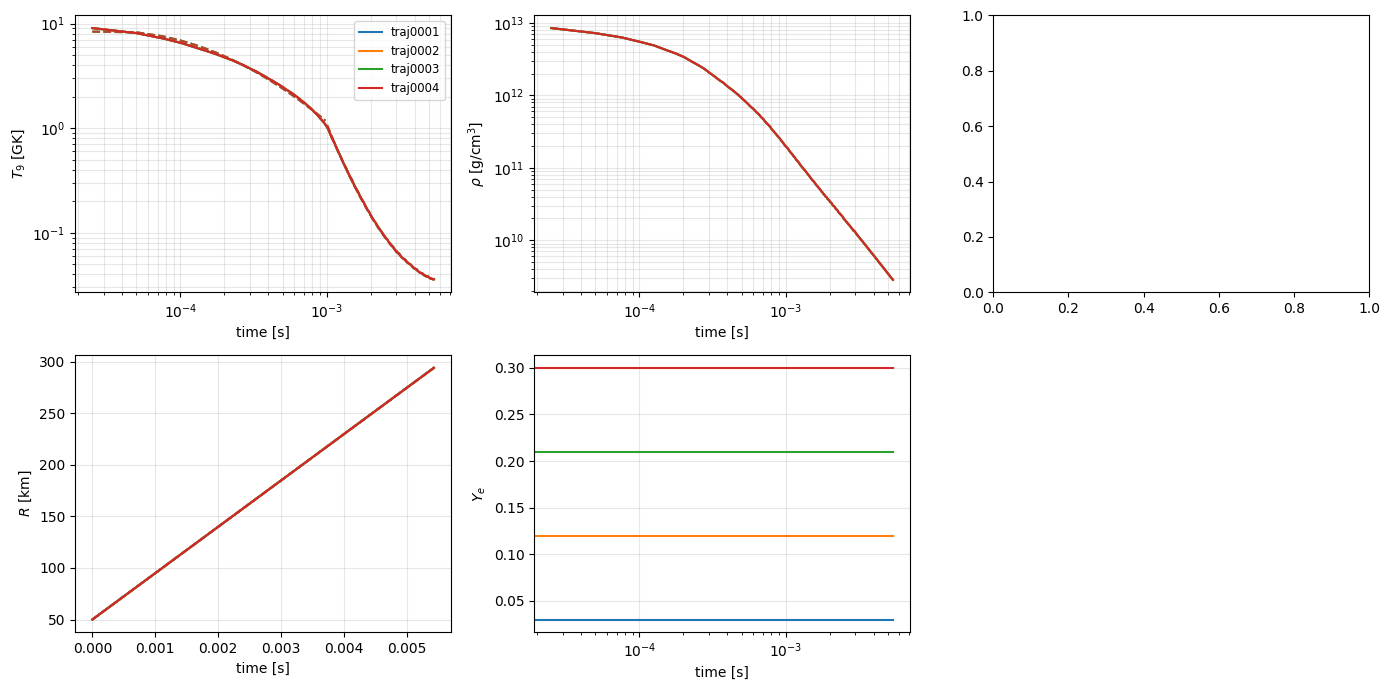

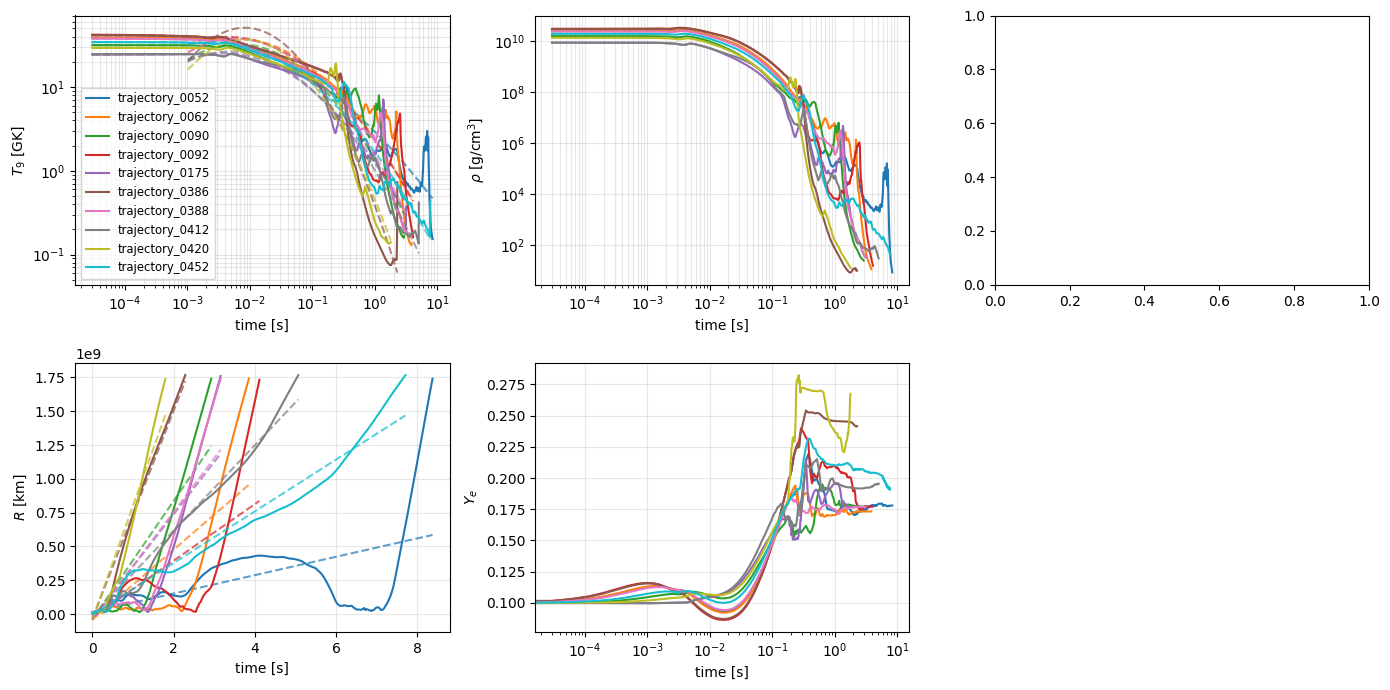

In [4]:
# Compare several trajectory files that share the same column format,
# e.g. all *.dat files in a directory.

def plot_trajectories(filepaths, figsize=(14, 7), split=-3.0):
    trajs = [read_trajectory(f) for f in filepaths]

    fig, axes = plt.subplots(2, 3, figsize=figsize, sharex=False)

    # T9: data + two quadratic fits split at log(t) = split
    ax_T9 = axes.flat[0]
    for traj in trajs:
        mask = traj['time'] > 0
        logt = np.log10(traj['time'][mask])
        line, = ax_T9.plot(traj['time'][mask], traj['T9'][mask], label=traj['name'])
        coeffs_low, coeffs_high = fit_logT9_quadratic_split(traj, split=split)
        if coeffs_low is not None:
            t_low = traj['time'][mask][logt < split]
            T9_low_fit = 10 ** np.polyval(coeffs_low, np.log10(t_low))
            ax_T9.plot(t_low, T9_low_fit, '--', color=line.get_color(), alpha=0.7)
        if coeffs_high is not None:
            t_high = traj['time'][mask][logt >= split]
            T9_high_fit = 10 ** np.polyval(coeffs_high, np.log10(t_high))
            ax_T9.plot(t_high, T9_high_fit, '--', color=line.get_color(), alpha=0.7)
    ax_T9.set_xscale('log')
    ax_T9.set_yscale('log')
    ax_T9.set_ylabel(r'$T_9$ [GK]')
    ax_T9.set_xlabel('time [s]')
    ax_T9.grid(alpha=0.3, which='both')

    # density: data + quadratic fit of log(rho) vs log(t) per trajectory
    ax_rho = axes.flat[1]
    for traj in trajs:
        mask = traj['time'] > 0
        ax_rho.plot(traj['time'][mask], traj['density'][mask], label=traj['name'])
    ax_rho.set_xscale('log')
    ax_rho.set_yscale('log')
    ax_rho.set_ylabel(r'$\rho$ [g/cm$^3$]')
    ax_rho.set_xlabel('time [s]')
    ax_rho.grid(alpha=0.3, which='both')


    # R: data + linear fit per trajectory
    ax_R = axes.flat[3]
    for traj in trajs:
        slope, intercept = fit_R_linear(traj)
        R_fit = slope * traj['time'] + intercept
        line, = ax_R.plot(traj['time'], traj['R'], label=traj['name'])
        ax_R.plot(traj['time'], R_fit, '--', color=line.get_color(), alpha=0.7)
    ax_R.set_ylabel(r'$R$ [km]')
    ax_R.set_xlabel('time [s]')
    ax_R.grid(alpha=0.3)

    # Ye
    ax_Ye = axes.flat[4]
    for traj in trajs:
        ax_Ye.plot(traj['time'], traj['Ye'], label=traj['name'])
    ax_Ye.set_ylabel(r'$Y_e$')
    ax_Ye.set_xlabel('time [s]')
    ax_Ye.set_xscale('log')
    ax_Ye.grid(alpha=0.3)

    axes.flat[5].axis('off')

    axes.flat[0].legend(fontsize='small')
    fig.tight_layout()
    return fig, axes

# Example: plot every trajectory file found in Data/Original_files/
trajectory_files = glob.glob('Data/Trajectories/*.dat')
plot_trajectories(trajectory_files)
plt.show()
trajectory_files_disk = glob.glob('Data/Original_files/NSM_Trajectories/disk/*.dat')
plot_trajectories(trajectory_files_disk)
plt.show()